In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import sys
import os
from pathlib import Path

package_path: str = ".."
if package_path not in sys.path:
    sys.path.append(package_path)
    print(f"Added {Path(package_path).resolve()} to sys.path")

working_dir: Path = Path.cwd()
while working_dir.name != "QoraFlow":
    working_dir = working_dir.parent
os.chdir(working_dir)
print(f"Current working directory set to {working_dir.resolve()}")

Added C:\WorkSpace\03_Develop\01_Analysis\QoraFlow to sys.path
Current working directory set to C:\WorkSpace\03_Develop\01_Analysis\QoraFlow


In [3]:
import numpy as np
import matplotlib.pyplot as plt

from QoraFlow.config import ConfigManager
from QoraFlow.integrator.loader import PalXFELLoader
from QoraFlow.filesystem import get_run_scan_dir

In [13]:
ConfigManager.initialize("config.yaml")

config = ConfigManager.load_config()
load_dir = config.path.load_dir
file = get_run_scan_dir(load_dir, 205, 1, sub_path="p0030.h5")
loader = PalXFELLoader(file)
data = loader.get_data()

pon_images = data["pon"]
pon_qbpm = data["pon_qbpm"]
print(f"{pon_images.shape=}")
print(f"{pon_qbpm.shape=}")

pon_images.shape=(300, 514, 1030)
pon_qbpm.shape=(300,)


Text(0.5, 1.0, 'PON Images mean')

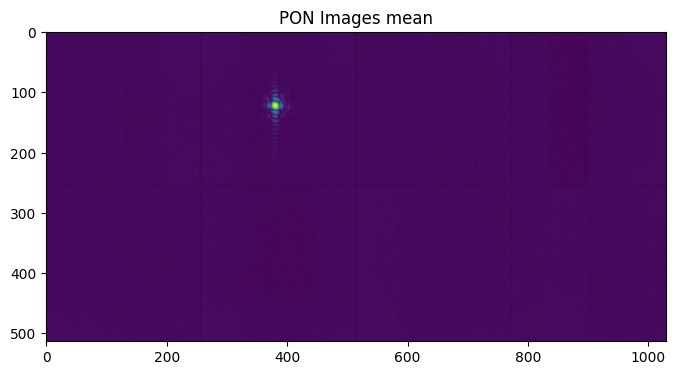

In [14]:
fig, ax = plt.subplots(1, 1, figsize=(8, 6))

ax.imshow(np.log1p(pon_images.mean(axis=0)), cmap="viridis")
ax.set_title("PON Images mean")

Text(0.5, 1.0, 'ROI Images mean')

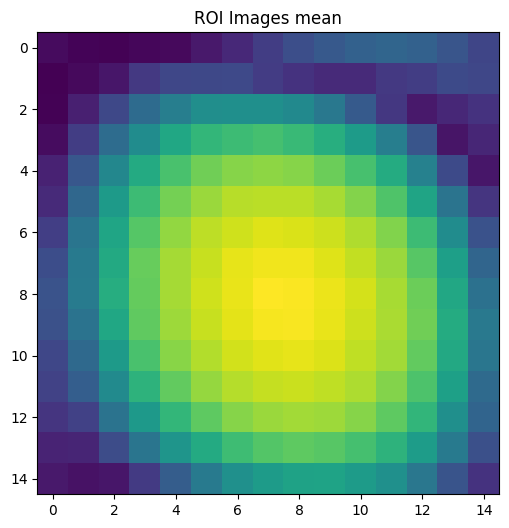

In [65]:
from roi_rectangle import RoiRectangle

fig, ax = plt.subplots(1, 1, figsize=(6, 6))
rect = RoiRectangle(115, 130, 373, 388)
imgs = rect.slice(pon_images)
ax.imshow(np.log1p(imgs.mean(axis=0)), cmap="viridis")
ax.set_title("ROI Images mean")

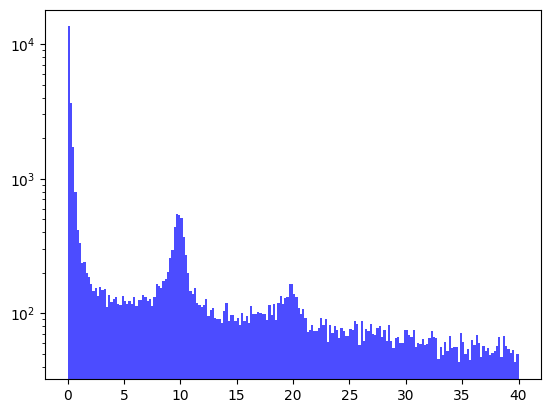

In [66]:
hist, bin_edges = np.histogram(imgs.ravel(), bins=200, range=(0, 40), density=None)

plt.bar(bin_edges[:-1], hist, width=np.diff(bin_edges), color='blue', alpha=0.7, align='edge')
plt.yscale('log')

[ 0 49 98]


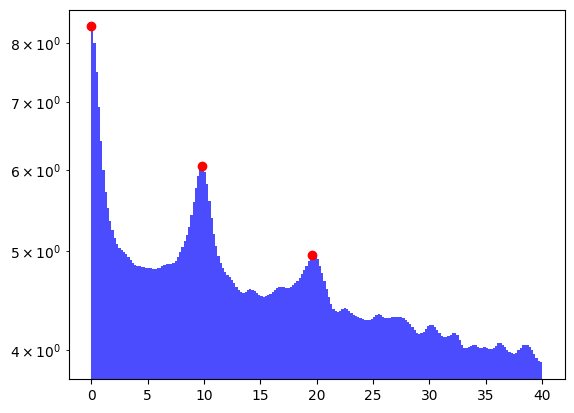

In [67]:
from scipy.signal import find_peaks
from scipy.ndimage import gaussian_filter

# Apply Gaussian filter to the histogram
soft_hist = gaussian_filter(np.log(hist), sigma=2)

# Find peaks in the filtered histogram
indices = find_peaks(soft_hist, distance=10, prominence=0.1, rel_height=0.5)[0]
indices = np.concatenate([[0], indices], axis=0)
print(indices)

plt.bar(bin_edges[:-1], soft_hist, width=np.diff(bin_edges), color='blue', alpha=0.7, align='edge')
plt.scatter(bin_edges[indices], soft_hist[indices], color='red', label='Peaks')
plt.yscale('log')

In [68]:
print("LSB is", np.diff(bin_edges[indices]).mean())

LSB is 9.8
